<a href="https://colab.research.google.com/github/rajeshkannan290208-create/FUTURE_ML_01/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Dataset path: /kaggle/input/superstore-dataset-final
Files: ['Sample - Superstore.csv']
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...

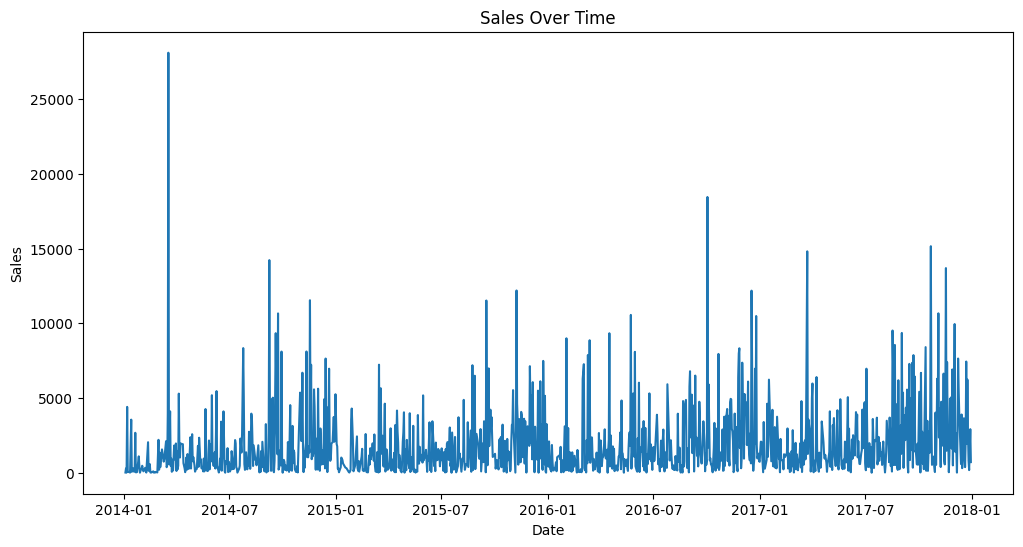

Mean Absolute Error: 1464.9132126478883


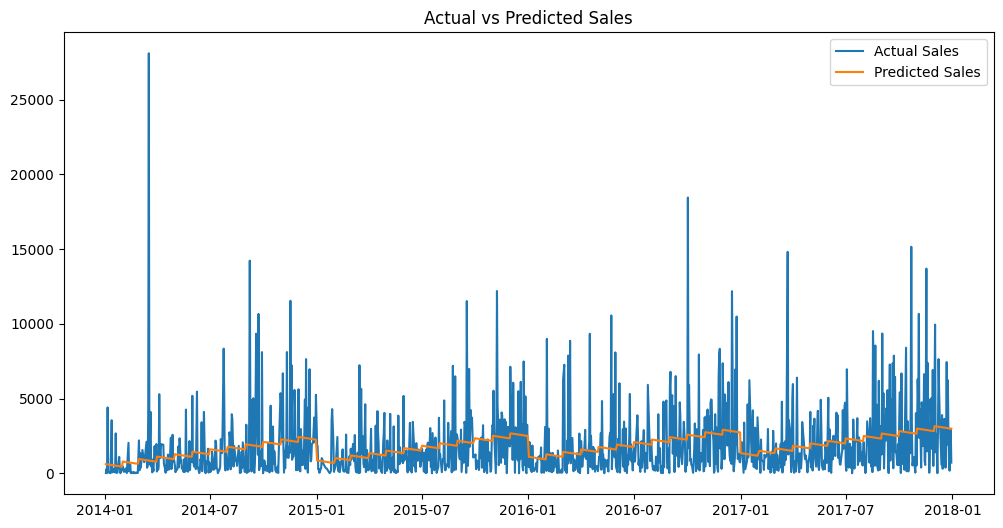


Future Sales Predictions:
Month 1 Prediction: 1589.195035380253
Month 2 Prediction: 1753.5826690386748
Month 3 Prediction: 1917.9703026970965


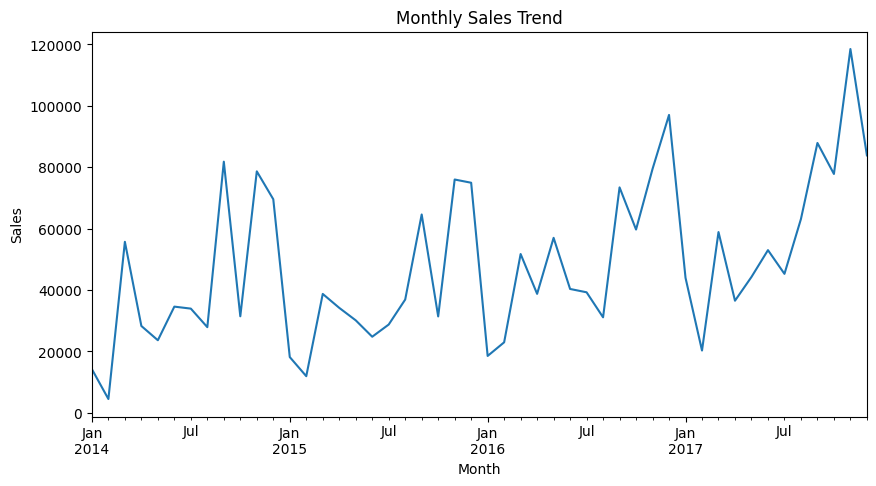

In [2]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Dataset path:", path)

# Check files inside folder
files = os.listdir(path)
print("Files:", files)

# Load the CSV file (auto-detect file name)
csv_file = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path, encoding='latin1')

print(df.head())
# ==============================
# SALES FORECASTING PROJECT
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error



# 3. Data Cleaning
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.dropna()
df = df.sort_values('Order Date')

# 4. Prepare Time-Series Data
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()

# 5. Feature Engineering
sales_data['year'] = sales_data['Order Date'].dt.year
sales_data['month'] = sales_data['Order Date'].dt.month
sales_data['day'] = sales_data['Order Date'].dt.day

# 6. Visualization - Sales Over Time
plt.figure(figsize=(12,6))
plt.plot(sales_data['Order Date'], sales_data['Sales'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# 7. Prepare Data for Model
X = sales_data[['year', 'month', 'day']]
y = sales_data['Sales']

# 8. Train Model
model = LinearRegression()
model.fit(X, y)

# 9. Predict on Training Data
y_pred = model.predict(X)

# 10. Evaluate Model
mae = mean_absolute_error(y, y_pred)
print("Mean Absolute Error:", mae)

# 11. Actual vs Predicted Graph
plt.figure(figsize=(12,6))
plt.plot(sales_data['Order Date'], y, label="Actual Sales")
plt.plot(sales_data['Order Date'], y_pred, label="Predicted Sales")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

# 12. Predict Future Sales
future = pd.DataFrame({
    'year': [2018, 2018, 2018],
    'month': [1, 2, 3],
    'day': [1, 1, 1]
})

future_predictions = model.predict(future)

print("\nFuture Sales Predictions:")
for i, val in enumerate(future_predictions):
    print(f"Month {i+1} Prediction:", val)

# 13. Monthly Sales Trend (Bonus)
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# ==============================
# END OF PROJECT
# ==============================